### Environment Setup
Required libraries:
- pandas
- numpy
- scikit-learn
- xgboost

In [7]:
import pandas as pd

df = pd.read_csv("../Data/clean_train.csv")

df.head()

,Id,AB,AF,AH,AM,AR,AX,AY,AZ,BC,...,GF,GH,GI,GL,Alpha,Beta,Gamma,Delta,Epsilon,Class
0,000ff2bfdfe9,0.209377,3109.03329,85.200147,22.394407,8.138688,0.699861,0.025578,9.812214,5.555634,...,2003.810319,22.136229,69.834944,0.120343,B,C,G,D,3/19/2019,1
1,007255e47698,0.145282,978.76416,85.200147,36.968889,8.138688,3.632190,0.025578,13.517790,1.229900,...,27981.562750,29.135430,32.131996,21.978000,A,C,M,B,Unknown,0
2,013f2bd269f5,0.470030,2635.10654,85.200147,32.360553,8.138688,6.732840,0.025578,12.824570,1.229900,...,13676.957810,28.022851,35.192676,0.196941,A,C,M,B,Unknown,0
3,043ac50845d5,0.252107,3819.65177,120.201618,77.112203,8.138688,3.685344,0.025578,11.053708,1.229900,...,2094.262452,39.948656,90.493248,0.155829,A,C,M,B,Unknown,0
4,044fb8a146ec,0.380297,3733.04844,85.200147,14.103738,8.138688,3.942255,0.054810,3.396778,102.151980,...,8524.370502,45.381316,36.262628,0.096614,D,B,F,B,3/25/2020,1


In [8]:
df.columns

Index(['Id', 'AB', 'AF', 'AH', 'AM', 'AR', 'AX', 'AY', 'AZ', 'BC', 'BD ', 'BN',
       'BP', 'BQ', 'BR', 'BZ', 'CB', 'CC', 'CD ', 'CF', 'CH', 'CL', 'CR', 'CS',
       'CU', 'CW ', 'DA', 'DE', 'DF', 'DH', 'DI', 'DL', 'DN', 'DU', 'DV', 'DY',
       'EB', 'EE', 'EG', 'EH', 'EJ', 'EL', 'EP', 'EU', 'FC', 'FD ', 'FE', 'FI',
       'FL', 'FR', 'FS', 'GB', 'GE', 'GF', 'GH', 'GI', 'GL', 'Alpha', 'Beta',
       'Gamma', 'Delta', 'Epsilon', 'Class'],
      dtype='object')

In [9]:
X = df.drop(columns=["Id", "Class"])
y = df["Class"]

In [10]:
print(df.dtypes)

Id          object
AB         float64
AF         float64
AH         float64
AM         float64
            ...   
Beta        object
Gamma       object
Delta       object
Epsilon     object
Class        int64
Length: 63, dtype: object


In [11]:
X = df.drop(columns=["Id", "Class", "EJ", "Alpha", "Beta", "Gamma", "Delta", "Epsilon"])
y = df["Class"]

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier


# split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# model
model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# train
model.fit(X_train, y_train)

# predict
pred = model.predict(X_valid)

# result
print("Accuracy:", accuracy_score(y_valid, pred))

Accuracy: 0.9112903225806451


## XGBoost Baseline
- Features used: cleaned numeric features only
- Dropped columns: Id, Class, EJ, Alpha, Beta, Gamma, Delta, Epsilon
- Validation split: 80/20
- Random state: 42
- Metric: Accuracy
- Baseline Accuracy: 0.9113

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, log_loss

pred_proba = model.predict_proba(X_valid)

print("Accuracy:", accuracy_score(y_valid, pred))
print("Log Loss:", log_loss(y_valid, pred_proba))
print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, pred))
print("\nClassification Report:")
print(classification_report(y_valid, pred))

Accuracy: 0.9112903225806451
Log Loss: 0.23018353424391613

Confusion Matrix:
[[99  3]
 [ 8 14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       102
           1       0.82      0.64      0.72        22

    accuracy                           0.91       124
   macro avg       0.87      0.80      0.83       124
weighted avg       0.91      0.91      0.91       124



In [14]:
configs = [
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.1},
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.05},
    {"n_estimators": 300, "max_depth": 4, "learning_rate": 0.05},
    {"n_estimators": 500, "max_depth": 5, "learning_rate": 0.03},
]

for cfg in configs:
    model = XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        learning_rate=cfg["learning_rate"]
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    pred_proba = model.predict_proba(X_valid)
    
    print("Config:", cfg)
    print("Accuracy:", accuracy_score(y_valid, pred))
    print("Log Loss:", log_loss(y_valid, pred_proba))
    print("-" * 50)

Config: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
Accuracy: 0.9112903225806451
Log Loss: 0.21603753419898367
--------------------------------------------------
Config: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}
Accuracy: 0.9032258064516129
Log Loss: 0.21674490703697283
--------------------------------------------------
Config: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05}
Accuracy: 0.9112903225806451
Log Loss: 0.22527324648106212
--------------------------------------------------
Config: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.03}
Accuracy: 0.9032258064516129
Log Loss: 0.21892810472807414
--------------------------------------------------


In [15]:
from sklearn.metrics import classification_report, confusion_matrix, log_loss

pred_proba = model.predict_proba(X_valid)

print("Accuracy:", accuracy_score(y_valid, pred))
print("Log Loss:", log_loss(y_valid, pred_proba))
print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, pred))
print("\nClassification Report:")
print(classification_report(y_valid, pred))

Accuracy: 0.9032258064516129
Log Loss: 0.21892810472807414

Confusion Matrix:
[[99  3]
 [ 9 13]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       102
           1       0.81      0.59      0.68        22

    accuracy                           0.90       124
   macro avg       0.86      0.78      0.81       124
weighted avg       0.90      0.90      0.90       124



The XGBoost baseline achieved an accuracy of approximately 91%.
However, further analysis revealed a significant class imbalance issue.
While the model performed well on Class 0, it struggled to correctly identify Class 1, with a recall of only 0.59.
This indicates that the model tends to favor the majority class, which is a critical limitation in a medical prediction task.

In [16]:
from sklearn.model_selection import cross_val_score

model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1
)

scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")

print("CV Accuracy:", scores)
print("Mean:", scores.mean())

CV Accuracy: [0.93548387 0.88709677 0.94308943 0.90243902 0.95121951]
Mean: 0.923865722528193


In [17]:
model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=102/22
)

model.fit(X_train, y_train)

pred = model.predict(X_valid)
pred_proba = model.predict_proba(X_valid)

from sklearn.metrics import classification_report, confusion_matrix, log_loss

print("Accuracy:", accuracy_score(y_valid, pred))
print("Log Loss:", log_loss(y_valid, pred_proba))
print(confusion_matrix(y_valid, pred))
print(classification_report(y_valid, pred))

Accuracy: 0.9274193548387096
Log Loss: 0.20367763765381128
[[99  3]
 [ 6 16]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       102
           1       0.84      0.73      0.78        22

    accuracy                           0.93       124
   macro avg       0.89      0.85      0.87       124
weighted avg       0.92      0.93      0.93       124



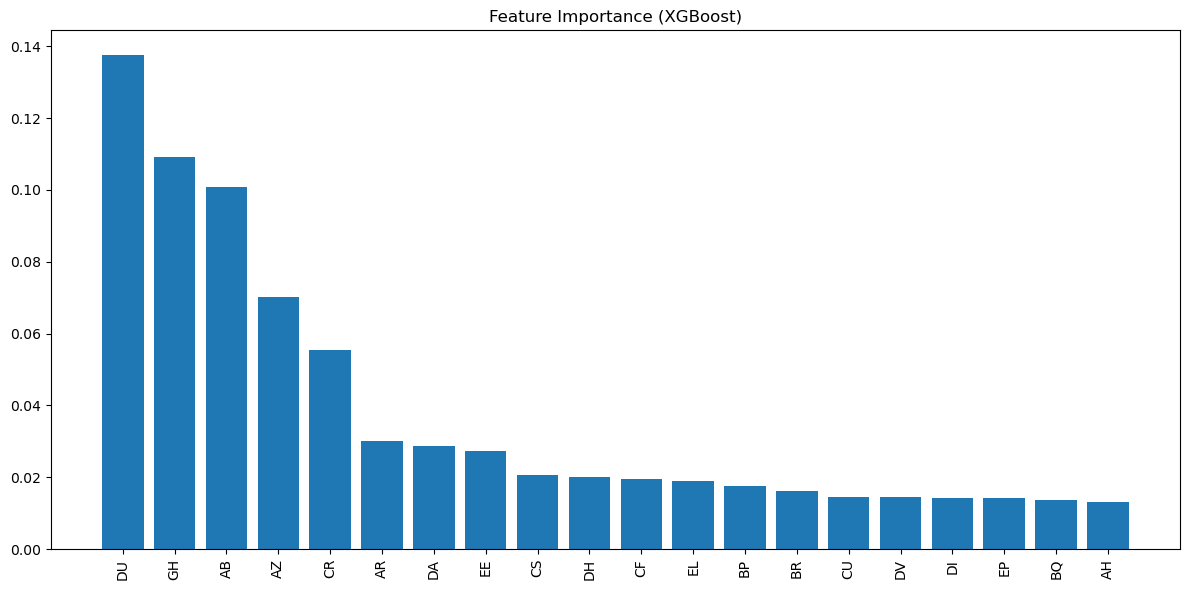

In [18]:
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np

model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=102/22
)

model.fit(X_train, y_train)

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

top_n = 20

plt.figure(figsize=(12, 6))
plt.title("Feature Importance (XGBoost)")
plt.bar(range(top_n), importances[indices][:top_n])
plt.xticks(range(top_n), X.columns[indices][:top_n], rotation=90)
plt.tight_layout()
plt.show()

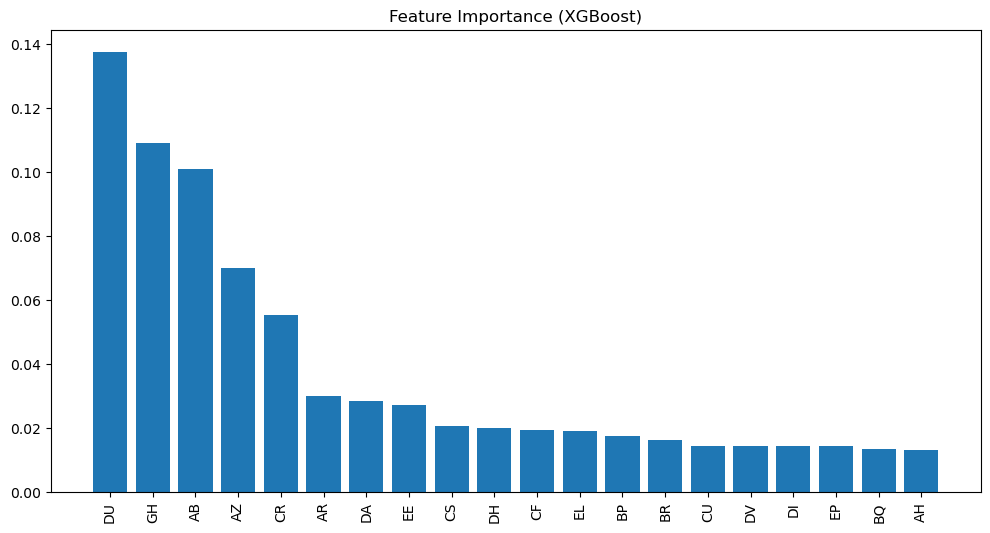

In [19]:
import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
plt.title("Feature Importance (XGBoost)")
plt.bar(range(20), importances[indices][:20])
plt.xticks(range(20), X.columns[indices][:20], rotation=90)
plt.show()

Model Accuracy Recall(Class1)

To better understand the model behavior, feature importance was extracted from the trained XGBoost model.
The results show that a small number of features dominate the prediction process.
In particular, features such as DU, GH, AB, AZ, and CR were identified as the most influential.

The importance scores decrease rapidly after the top features, indicating that the model relies heavily on a limited subset of variables.
This suggests that not all features contribute equally, and some may have minimal impact on the prediction performance.

This insight is valuable for both model interpretability and potential feature selection in future improvements.

### Model Performance Comparison

| Model                | Accuracy | Recall (Class 1) | Log Loss |
|---------------------|----------|------------------|----------|
| XGBoost Baseline    | 0.91     | 0.59             | 0.216    |
| XGBoost Weighted    | 0.927    | 0.73             | 0.203    |

### XGBoost Performance Evaluation

The XGBoost baseline model achieved an accuracy of approximately 91%. 
However, the model showed poor performance in detecting the minority class (Class 1), 
with a recall of only 0.59.

To address this issue, class imbalance handling was applied using the `scale_pos_weight` parameter. 
After this adjustment, the model performance improved significantly. 
The recall for Class 1 increased to 0.73, while the overall accuracy improved to 92.7%.

Additionally, log loss decreased from 0.216 to 0.203, indicating better probability estimation. 
These results demonstrate that handling class imbalance is critical for improving model performance in this task.

Improving recall for Class 1 is particularly important in this context, 
as it represents correctly identifying individuals with age-related conditions.

### Feature Importance Analysis

To better understand the model behavior, feature importance was extracted from the trained XGBoost model.

The results show that a small number of features dominate the prediction process. 
In particular, features such as DU, GH, AB, AZ, and CR were identified as the most influential.

The importance scores decrease rapidly after the top features, indicating that the model relies heavily on a limited subset of variables. 
This suggests that not all features contribute equally, and some may have minimal impact on the prediction performance.

This insight is valuable for both model interpretability and potential feature selection in future improvements.

In [ ]:
from pathlib import Path

REPORTS_DIR = Path("../Reports")
REPORTS_DIR.mkdir(exist_ok=True)

xgb_probs = pd.DataFrame({
    "Class": y_valid.values,
    "XGBoost Weighted": pred_proba[:, 1]
})

xgb_probs.to_csv(REPORTS_DIR / "xgboost_probabilities.csv", index=False)

print("Saved XGBoost probabilities.")